# Movie Recommendation System
---

---
## 1: Business Understanding

### 1.1 Business Context

The company intends to launch a video streaming platform to compete with established services such as Netflix, Amazon Prime, and Disney+. However, the company currently lacks content expertise — it does not know which movies to surface to which users, or how to personalise the viewing experience.

A key driver of revenue in streaming is **user retention**. Research consistently shows that personalised recommendations reduce churn and increase time-on-platform. Without a recommendation engine, new users face a blank or generic catalogue, which leads to early drop-off.

This project addresses that gap by building a **movie recommendation system** using the MovieLens dataset. The system will learn from user rating behaviour and surface the **top 5 personalised movie recommendations** for any given user.


### 1.2 Stakeholders

| Stakeholder | Interest |
|---|---|
| **Streaming Platform (Business)** | Increase user retention & revenue |
| **End Users** | Discover movies they enjoy quickly |
| **Movie Studios / Content Providers** | Surface their content to relevant audiences |
| **Data / Engineering Teams** | Build and maintain the model pipeline |


### 1.3 Project Plan (CRISP-DM Phases)

```
Phase 1: Business Understanding  
Phase 2: Data Understanding      
Phase 3: Data Preparation        
Phase 4: Modeling                
Phase 5: Evaluation              
Phase 6: Deployment              
```

**Deliverables:**
- Jupyter Notebook (this file)
- GitHub Repository
- Tableau Story (EDA visualisations)
- Non-Technical Presentation (slides)
- Streamlit Deployment


---
## 2: Data Understanding


### 2.1 Overview - MovieLens (Small)

The dataset is sourced from the GroupLens Research Lab at the University of Minnesota.  
It contains **100,836 ratings** applied to **9,742 movies** by **610 users** collected between 1996 and 2018.


| File | Rows (approx.) | Key Columns | Description |
|---|---|---|---|
| `ratings.csv` | 100,836 | `userId`, `movieId`, `rating`, `timestamp` | Core user–movie interactions |
| `movies.csv` | 9,742 | `movieId`, `title`, `genres` | Movie metadata |
| `tags.csv` | 3,683 | `userId`, `movieId`, `tag`, `timestamp` | textual user tags |
| `links.csv` | 9,742 | `movieId`, `imdbId`, `tmdbId` | external IDs |


### 2.2 Import Libraries


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import ndcg_score

from surprise import Dataset, Reader
from surprise import SVD, KNNBasic, KNNWithMeans, accuracy
from surprise.model_selection import cross_validate, train_test_split as surprise_split, GridSearchCV


### 2.3 Load Individual Files


In [76]:
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')
tags    = pd.read_csv('tags.csv')
links   = pd.read_csv('links.csv')

print(f"ratings : {ratings.shape}")
print(f"movies  : {movies.shape}")
print(f"tags    : {tags.shape}")
print(f"links   : {links.shape}")


ratings : (100836, 4)
movies  : (9742, 3)
tags    : (3683, 4)
links   : (9742, 3)


### 2.4 Preview Each File


In [77]:
ratings.head()
print(ratings.dtypes)


userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object


In [78]:
movies.head()
print(movies.dtypes)


movieId     int64
title      object
genres     object
dtype: object


In [79]:
tags.head()
print(tags.dtypes)


userId        int64
movieId       int64
tag          object
timestamp     int64
dtype: object


In [80]:
links.head()
print(links.dtypes)


movieId      int64
imdbId       int64
tmdbId     float64
dtype: object


### 2.5 Descriptive Statistics


In [81]:
ratings.describe()

tags.describe(include='all')


,userId,movieId,tag,timestamp
count,3683.000000,3683.000000,3683,3.683000e+03
unique,NaN,NaN,1589,NaN
top,NaN,NaN,In Netflix queue,NaN
freq,NaN,NaN,131,NaN
mean,431.149335,27252.013576,NaN,1.320032e+09
std,158.472553,43490.558803,NaN,1.721025e+08
min,2.000000,1.000000,NaN,1.137179e+09
25%,424.000000,1262.500000,NaN,1.137521e+09
50%,474.000000,4454.000000,NaN,1.269833e+09
75%,477.000000,39263.000000,NaN,1.498457e+09


### 2.6 Missing Value Audit


In [82]:
def missing_summary(df, name):
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(2)
    result  = pd.DataFrame({'missing': missing, 'pct_%': pct})
    
    display(result[result['missing'] > 0] if result['missing'].sum() > 0
            else pd.DataFrame({'status': ['No missing values']}, index=[name]))

missing_summary(ratings, 'ratings')
missing_summary(movies,  'movies')
missing_summary(tags,    'tags')
missing_summary(links,   'links')


,status
ratings,No missing values


,status
movies,No missing values


,status
tags,No missing values


,missing,pct_%
tmdbId,8,0.08


### 2.7 Rating Distribution


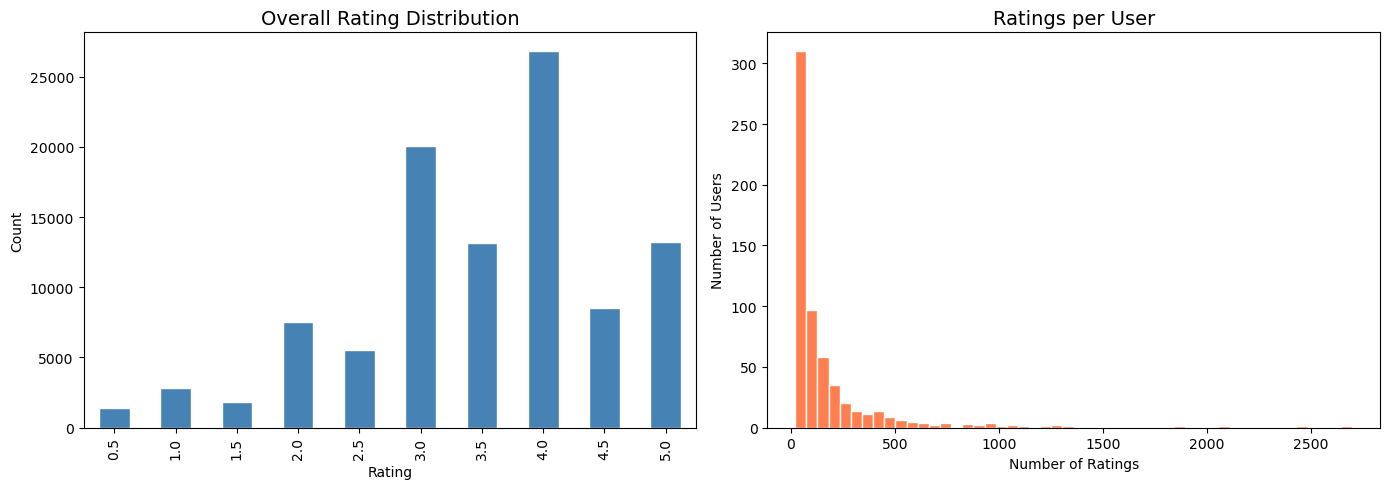


Rating scale  : 0.5 – 5.0
Mean rating   : 3.502
Median rating : 3.5
Unique users  : 610
Unique movies : 9724


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Overall Rating Distribution', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()
axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per User', fontsize=14)
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

print(f"\nRating scale  : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Mean rating   : {ratings['rating'].mean():.3f}")
print(f"Median rating : {ratings['rating'].median():.1f}")
print(f"Unique users  : {ratings['userId'].nunique()}")
print(f"Unique movies : {ratings['movieId'].nunique()}")


### 2.8 Sparsity of the Ratings Matrix


In [84]:
n_users  = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

sparsity = 1 - n_ratings / (n_users * n_movies)
print(f"Users         : {n_users}")
print(f"Movies        : {n_movies}")
print(f"Total ratings : {n_ratings}")
print(f"Matrix size   : {n_users} x {n_movies} = {n_users * n_movies:,}")
print(f"Sparsity      : {sparsity:.4%}")


Users         : 610
Movies        : 9724
Total ratings : 100836
Matrix size   : 610 x 9724 = 5,931,640
Sparsity      : 98.3000%


**Interpretation:** The ratings matrix is extremely sparse. Most user–movie combinations have no rating. This is why collaborative filtering (and SVD in particular) is necessary; it can generalise from the observed ratings to predict missing ones.


### 2.9 Genre Distribution


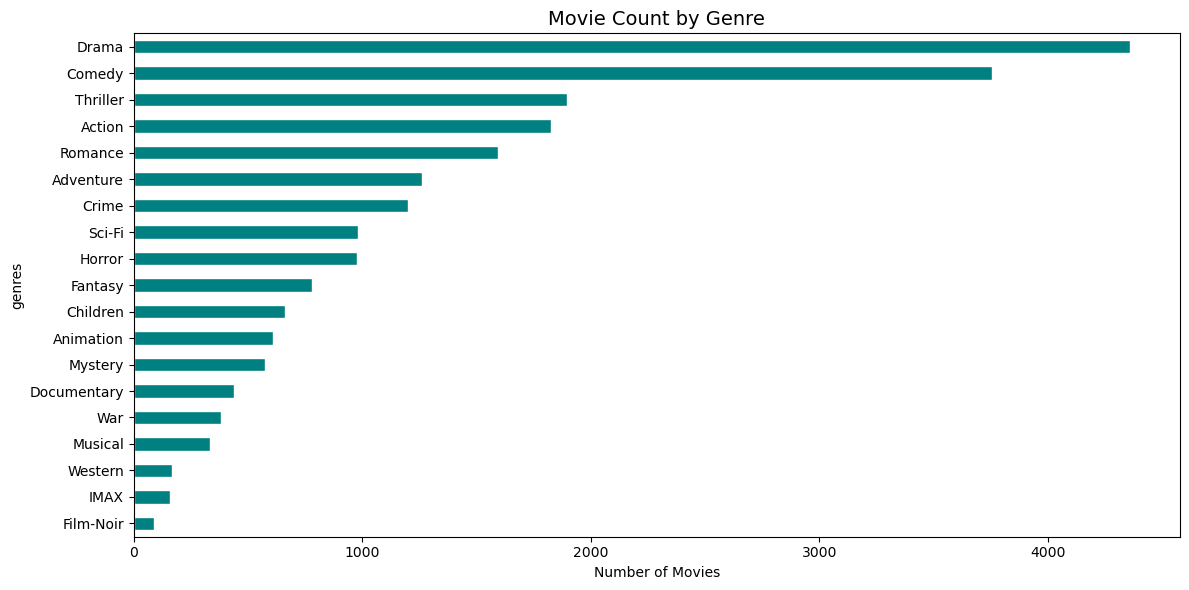

In [85]:
genre_series = movies['genres'].str.split('|').explode()
genre_counts = genre_series.value_counts().drop('(no genres listed)', errors='ignore')

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='barh', color='teal', edgecolor='white')
plt.title('Movie Count by Genre', fontsize=14)
plt.xlabel('Number of Movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 2.10 Most-Rated and Highest-Rated Movies


In [86]:
# Most rated movies (popularity)
most_rated = (ratings.groupby('movieId')['rating']
                      .count()
                      .reset_index(name='n_ratings')
                      .merge(movies[['movieId','title']], on='movieId')
                      .sort_values('n_ratings', ascending=False)
                      .head(10))

print("Top 10 Most-Rated Movies:")
display(most_rated[['title','n_ratings']].reset_index(drop=True))

# Highest average rating (min 50 ratings to avoid noise)
best_rated = (ratings.groupby('movieId')['rating']
                      .agg(['mean','count'])
                      .reset_index()
                      .rename(columns={'mean':'avg_rating','count':'n_ratings'})
                      .query('n_ratings >= 50')
                      .merge(movies[['movieId','title']], on='movieId')
                      .sort_values('avg_rating', ascending=False)
                      .head(10))

print("\nTop 10 Highest-Rated Movies (min 50 ratings):")
best_rated[['title','avg_rating','n_ratings']].reset_index(drop=True)


Top 10 Most-Rated Movies:


,title,n_ratings
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278
5,Star Wars: Episode IV - A New Hope (1977),251
6,Jurassic Park (1993),238
7,Braveheart (1995),237
8,Terminator 2: Judgment Day (1991),224
9,Schindler's List (1993),220



Top 10 Highest-Rated Movies (min 50 ratings):


,title,avg_rating,n_ratings
0,"Shawshank Redemption, The (1994)",4.429022,317
1,"Godfather, The (1972)",4.289062,192
2,Fight Club (1999),4.272936,218
3,Cool Hand Luke (1967),4.271930,57
4,Dr. Strangelove or: How I Learned to Stop Worr...,4.268041,97
5,Rear Window (1954),4.261905,84
6,"Godfather: Part II, The (1974)",4.259690,129
7,"Departed, The (2006)",4.252336,107
8,Goodfellas (1990),4.250000,126
9,Casablanca (1942),4.240000,100


### 2.11 Tag Analysis


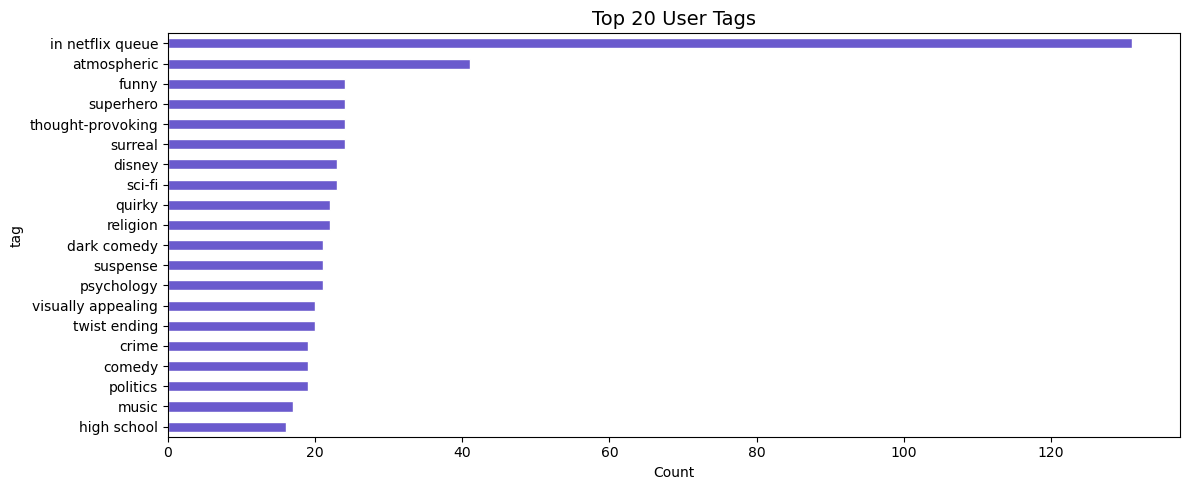

In [87]:
# Most common tags
top_tags = (tags['tag'].str.lower()
                       .value_counts()
                       .head(20))

plt.figure(figsize=(12, 5))
top_tags.plot(kind='barh', color='slateblue', edgecolor='white')
plt.title('Top 20 User Tags', fontsize=14)
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


---
## 3: Data Preparation


### 3.1 Merge All Four Files

We build a single master DataFrame by joining all four files on their shared keys.  

```
ratings  ──[movieId]──>  movies
         ──[movieId]──>  links
         ──[userId, movieId]──>  tags  (aggregated first)
```


In [88]:
user_movie_tags = tags.groupby(["userId", "movieId"])["tag"].apply( # to show how each user describes a certain movie
    lambda x: " ".join(x.astype(str).str.lower())
).reset_index()

print(f"Aggregated tags shape: {user_movie_tags.shape}")
user_movie_tags.head()

Aggregated tags shape: (1775, 3)


,userId,movieId,tag
0,2,60756,funny highly quotable will ferrell
1,2,89774,boxing story mma tom hardy
2,2,106782,drugs leonardo dicaprio martin scorsese
3,7,48516,way too long
4,18,431,al pacino gangster mafia


In [89]:
df = ratings.merge(movies, on='movieId', how='left')
print(f"After ratings + movies : {df.shape}")


After ratings + movies : (100836, 6)


In [90]:
df = df.merge(links, on='movieId', how='left')
print(f"After + links          : {df.shape}")


After + links          : (100836, 8)


In [91]:
df = df.merge(user_movie_tags, on=['userId', 'movieId'], how='left')
print(f"After + tags           : {df.shape}")

df.head()

After + tags           : (100836, 9)


,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId,tag
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,NaN
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,NaN
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,113277,949.0,NaN
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0,NaN
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0,NaN


### 3.2 Clean the DataFrame


In [92]:
# Convert timestamp to datetime
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df = df.drop(columns=['timestamp'])

# Extract year from title
df['year'] = df['title'].str.extract(r'\((\d{4})\)').astype(float)

# Normalise tags
df["tag"] = (
    df["tag"]
    .fillna('')
    .str.lower()
    .str.replace("-", " ", regex=False) # replace hyphen with empty string ""
    .str.replace(r"[^\w\s]", "", regex=True) # replace anything that's not a word character A-Z, 0-9 or whitespace with an empty string ""
    .str.strip() # remove spaces from beginning and end of string
)

# Check for duplicates
dupes = df.duplicated(subset=['userId','movieId']).sum()
print(f"Duplicate (userId, movieId) pairs: {dupes}")
if dupes > 0:
    df = df.drop_duplicates(subset=['userId','movieId'], keep='last')

# Missing value check after merge
print("\nMissing values in master df:")
df.isnull().sum()[df.isnull().sum() > 0]
print(f"\nFinal shape: {df.shape}")


Duplicate (userId, movieId) pairs: 0

Missing values in master df:

Final shape: (100836, 10)


### 3.3 Feature Engineering


In [93]:
# Convert genres into clean string
df['genres_clean'] = df['genres'].str.replace('|', ' ', regex=False)

movie_text = (
    df.groupby('movieId')
      .agg(
          genres=('genres_clean', 'first'),
          tags=('tag', lambda x: ' '.join(x.dropna().unique()))
      )
      .reset_index()
)

# Merge title
movie_text = movie_text.merge(movies[['movieId', 'title']], on='movieId')

# Extract year
movie_text['year'] = movie_text['title'].str.extract(r'(\d{4})')[0].fillna('')

# Build content string
movie_text['content'] = (
    movie_text['genres'] + ' ' +
    movie_text['tags'] + ' ' +
    movie_text['title'] + ' ' +
    movie_text['year']
)

In [94]:
df

,userId,movieId,rating,title,genres,imdbId,tmdbId,tag,datetime,year,genres_clean
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.0,,2000-07-30 18:45:03,1995.0,Adventure Animation Children Comedy Fantasy
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance,113228,15602.0,,2000-07-30 18:20:47,1995.0,Comedy Romance
2,1,6,4.0,Heat (1995),Action|Crime|Thriller,113277,949.0,,2000-07-30 18:37:04,1995.0,Action Crime Thriller
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.0,,2000-07-30 19:03:35,1995.0,Mystery Thriller
4,1,50,5.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.0,,2000-07-30 18:48:51,1995.0,Crime Mystery Thriller
...,...,...,...,...,...,...,...,...,...,...,...
100831,610,166534,4.0,Split (2017),Drama|Horror|Thriller,4972582,381288.0,,2017-05-03 21:53:22,2017.0,Drama Horror Thriller
100832,610,168248,5.0,John Wick: Chapter Two (2017),Action|Crime|Thriller,4425200,324552.0,heroic bloodshed,2017-05-03 22:21:31,2017.0,Action Crime Thriller
100833,610,168250,5.0,Get Out (2017),Horror,5052448,419430.0,,2017-05-08 19:50:47,2017.0,Horror
100834,610,168252,5.0,Logan (2017),Action|Sci-Fi,3315342,263115.0,,2017-05-03 21:19:12,2017.0,Action Sci-Fi


In [95]:
movie_text

,movieId,genres,tags,title,year,content
0,1,Adventure Animation Children Comedy Fantasy,pixar fun,Toy Story (1995),1995,Adventure Animation Children Comedy Fantasy p...
1,2,Adventure Children Fantasy,fantasy magic board game robin williams game,Jumanji (1995),1995,Adventure Children Fantasy fantasy magic boar...
2,3,Comedy Romance,moldy old,Grumpier Old Men (1995),1995,Comedy Romance moldy old Grumpier Old Men (19...
3,4,Comedy Drama Romance,,Waiting to Exhale (1995),1995,Comedy Drama Romance Waiting to Exhale (1995)...
4,5,Comedy,pregnancy remake,Father of the Bride Part II (1995),1995,Comedy pregnancy remake Father of the Bride P...
...,...,...,...,...,...,...
9719,193581,Action Animation Comedy Fantasy,,Black Butler: Book of the Atlantic (2017),2017,Action Animation Comedy Fantasy Black Butler:...
9720,193583,Animation Comedy Fantasy,,No Game No Life: Zero (2017),2017,Animation Comedy Fantasy No Game No Life: Zer...
9721,193585,Drama,,Flint (2017),2017,Drama Flint (2017) 2017
9722,193587,Action Animation,,Bungo Stray Dogs: Dead Apple (2018),2018,Action Animation Bungo Stray Dogs: Dead Apple...


### 3.4 Prepare the Surprise Dataset (for Collaborative Filtering)

The `Surprise` library expects a specific dataset format built from the ratings file.


In [96]:
reader  = Reader(rating_scale=(ratings['rating'].min(), ratings['rating'].max()))
data    = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

print("Surprise dataset created.")
print(f"Rating scale: {ratings['rating'].min()} – {ratings['rating'].max()}")


Surprise dataset created.
Rating scale: 0.5 – 5.0


---
## 4: Modeling

### **Collaborative:**

*“People like you liked this artist”*

$$SVD(u, i) = r_{ui}$$

- This model predicts how much a user u will like an item i based on patterns from users with similar behaviour. It does not look at the item's features

$$
r_{ui} \text{ represents the predicted rating or preference score of user } u \text{ for item } i
$$

`How it works`

- creates a matrix to map user behaviour for each item in the system. Each user's individual preference for each item is displayed in a user-item matrix /user rating matrix, like so:

|        | Artist1 | Artist2 | Artist3 |
| ------ | ------- | ------- | ------- |
|  User1 | 10      |  0      |  5      |
|  User2 |  0      | 20      |  0      |

**when users' preferences for items are limited it leaves the matrix sparse

- Plots values from the matrix
- The distance btn points is measured to calculate user-user and item-item similarity (think cosine similarity, btn -1 and 1. the higher the score is, the more alike two items are. the points being compared are a subset of ratings for a given user or item)

**there are 2 primary types of collaborative filtering**

`1. MEMORY-BASED` (neighbour based); 

> |a.| user-based 

assigns each user a 'weight' representing their perceived similarity with the target user , ie the target user's neighbours

then it selects *n* users with the highest weights and predicts the target user's behaviour from a weighted average of the selected neighbours' behaviour

> |b.| item-based

recommends new items to a target user based on that user's behaviour towards similar items

**HOWEVER**, in comparing items, the collaborative system does not compare item features (as in content-based filtering), but instead how users interact with those items

for example: if the target user rated movie *a* and movie *b* highly but has not seen movie *c*, and other users who rated the former two highly also rated the third highly, the system will recommend movie *c* to the target user

`2. MODEL-BASED`

These create a predictive ML model that uses values in the user-item matrix as the training dataset and produces predictions for the missing values

Can use *ML algorithms like decision trees, neural networks, Bayes classifiers.. etc*

or a latent factor model like *Matrix factorization*
> `n_factors` represents the hidden aspects of preference (discovered by the model) used to represent users and items. each user and each artist becomes a vector of length n, for instance: [User A becomes [0.2, -0.5, 1.3, ..., 0.7]]. The products of the user_vector and item_vector is used to make predictions

*n_factors* controls how complex the model’s understanding of taste is


### **Content-based:**

*“This artist is similar to artists you like”*


- This model recommends items based on item features. Targeting recommendations to one specific user's preferences rather than a group, as in collaborative filtering

*How the score is computed*
- Compare item i with all artists the user has liked
- Compute a similarity score (e.g., cosine similarity)
- Aggregate those similarities

Works even if few users have rated the item



## 4.1 Collaborative Filtering
### **SVD (matrix factorization)**

In [97]:
## split the data into training and testing sets

trainset, testset = surprise_split(data, test_size=0.3, random_state=42)

In [98]:
## Instantiate the SVD model
Svd_model = SVD(n_factors=50, random_state=42)

In [99]:
## fit the model
Svd_model.fit(trainset)

In [100]:
## predictions and evaluation  
predictions = Svd_model.test(testset)
print(accuracy.rmse(predictions))

RMSE: 0.8760
0.8759627174238854


In [101]:
## Hyperparameter Tuning

param_grid = {'n_factors': [20, 50],
                'n_epochs': [10, 25],
                'lr_all': [0.001, 0.005],
                'reg_all': [0.02, 0.07]}


In [102]:
grid_search = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=8)
grid_search.fit(data)

In [103]:
## Re-evaluate the best model on the test set
best_svd = grid_search.best_estimator['rmse']
best_svd.fit(trainset)

In [104]:
## Recommendation

def get_top_n(best_svd, trainset, data, user_Id, n=5):
    # Get all movieIds
    all_movie_ids = set(data.df['movieId'].unique())
    
    # Get movies the user has already rated
    user_rated_movies = set(trainset.ur[trainset.to_inner_uid(user_Id)])
    
    # Predict ratings for all unrated movies
    predictions = []
    for movie_id in all_movie_ids:
        if movie_id not in user_rated_movies:
            pred = best_svd.predict(user_Id, movie_id)
            predictions.append((movie_id, pred.est))
    
    # Sort predictions by estimated rating and return top n
    top_n = sorted(predictions, key=lambda x: x[1], reverse=True)[:n]
    return top_n
print(get_top_n(best_svd,trainset,data, user_Id=1, n=5))

[(50, 5.0), (296, 5.0), (318, 5.0), (356, 5.0), (475, 5.0)]



### **KNN**

In [105]:
# User-based KNN 
sim_options_user = {'name': 'cosine', 'user_based': True}
knn_user = KNNWithMeans(k=40, sim_options=sim_options_user, verbose=False)
knn_user.fit(trainset)

knn_user_preds = knn_user.test(testset)
knn_user_rmse  = accuracy.rmse(knn_user_preds, verbose=False)
knn_user_mae   = accuracy.mae(knn_user_preds,  verbose=False)

print(f"KNN (user-based)  RMSE : {knn_user_rmse:.4f}")
print(f"KNN (user-based)  MAE  : {knn_user_mae:.4f}")


KNN (user-based)  RMSE : 0.9072
KNN (user-based)  MAE  : 0.6940


In [106]:
param_grid_u = {
    'k'          : [20, 40, 60],
    'sim_options': {
        'name':['cosine','pearson'],
        'user_based':[True]
    }
}


In [107]:
gs_knn_user = GridSearchCV(KNNWithMeans, param_grid_u, measures=['rmse'], cv=8)
gs_knn_user.fit(data)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computi

In [108]:
best_knn_user = gs_knn_user.best_estimator['rmse']

best_knn_user.fit(trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


In [109]:
#Recommendation with best KNN model
def recommend_movies_user_based(best_knn_user, trainset, raw_user_id, data, n=5):
    
    # Convert raw user → inner user id
    inner_user_id = trainset.to_inner_uid(raw_user_id)
    
    # Items already rated by user
    rated_items = set([trainset.to_raw_iid(iid) 
                       for (iid, _) in trainset.ur[inner_user_id]])
    
    # All items in dataset
    all_items = set([iid for (_, iid, _, _) in data.raw_ratings])
    
    # Items to predict (not rated)
    items_to_predict = all_items - rated_items
    
    predictions = []
    
    for item_id in items_to_predict:
        pred = best_knn_user.predict(raw_user_id, item_id)
        predictions.append((item_id, pred.est))
    
    # Sort by predicted rating (highest first)
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    return predictions[:n]


In [110]:
top_recommendations = recommend_movies_user_based(
    best_knn_user,
    trainset=trainset,
    raw_user_id=5,
    data=data,
    n=5
)

print(top_recommendations)    

[(99, 5.0), (199, 5.0), (495, 5.0), (633, 5.0), (1310, 5.0)]


In [111]:
movie_dict = dict(zip(movies['movieId'], movies['title']))
for movie_id, rating in top_recommendations:
    title = movie_dict.get(int(movie_id), "Unknown")
    print(f"{title}  --> Predicted Rating: {rating:.2f}")

Heidi Fleiss: Hollywood Madam (1995)  --> Predicted Rating: 5.00
Umbrellas of Cherbourg, The (Parapluies de Cherbourg, Les) (1964)  --> Predicted Rating: 5.00
In the Realm of the Senses (Ai no corrida) (1976)  --> Predicted Rating: 5.00
Denise Calls Up (1995)  --> Predicted Rating: 5.00
Hype! (1996)  --> Predicted Rating: 5.00


In [112]:
# Item-based KNN
sim_options_item = {'name': 'cosine', 'user_based': False}
knn_item = KNNWithMeans(k=40, sim_options=sim_options_item, verbose=False)
knn_item.fit(trainset)

knn_item_preds = knn_item.test(testset)
knn_item_rmse  = accuracy.rmse(knn_item_preds, verbose=False)
knn_item_mae   = accuracy.mae(knn_item_preds,  verbose=False)

print(f"KNN (item-based)  RMSE : {knn_item_rmse:.4f}")
print(f"KNN (item-based)  MAE  : {knn_item_mae:.4f}")


KNN (item-based)  RMSE : 0.9110
KNN (item-based)  MAE  : 0.6959


In [113]:
param_grid_i = {
    'k'          : [20, 40, 60],
    'sim_options': {
        'name':['cosine','pearson'],
        'user_based':[False]
    }
}

In [114]:
gs_knn_item = GridSearchCV(KNNWithMeans, param_grid_i, measures=['rmse'], cv=8)
gs_knn_item.fit(data)

Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computi

In [115]:
best_knn_item = gs_knn_item.best_estimator['rmse']

best_knn_item.fit(trainset)

Computing the pearson similarity matrix...
Done computing similarity matrix.


## Content-based Filtering
### **TF-IDF**

In [116]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [117]:
train_movie_ids = train_df['movieId'].unique()

train_movie_text = (movie_text[movie_text['movieId'].isin(train_movie_ids)].reset_index(drop=True))

In [118]:
# vectorization
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),     # captures phrases ("space war")
    min_df=2,               # ignore rare noise
    max_df=0.8,             # ignore overly common terms
    sublinear_tf=True       # better scaling
)
tfidf_matrix = tfidf.fit_transform(train_movie_text['content'])

In [119]:
movie_id_to_index = dict(zip(train_movie_text['movieId'], train_movie_text.index))
title_to_index    = dict(zip(train_movie_text['title'], train_movie_text.index))

In [120]:
def recommend_similar_movies(title, n=5):
    
    if title not in title_to_index:
        return "Movie not found"
    
    idx = title_to_index[title]
    
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    
    # Exclude itself and get top-N
    top_idx = sim_scores.argsort()[-(n+1):-1][::-1]
    
    return train_movie_text['title'].iloc[top_idx].tolist()


In [121]:
recommend_similar_movies("Toy Story (1995)")

['Toy Story 3 (2010)',
 'Toy Story 2 (1999)',
 'Balto (1995)',
 'Gordy (1995)',
 'Reckless (1995)']

In [122]:
# tf idf system 2
# instead of recommending based on one movie, we build a user profile from all their liked movies

def build_user_profile(user_id, df):
    
    user_data = train_df[train_df['userId'] == user_id]
    
    movie_indices = []
    ratings = []
    
    for _, row in user_data.iterrows():
        movie_id = row['movieId']
        
        if movie_id in movie_id_to_index:
            movie_indices.append(movie_id_to_index[movie_id])
            ratings.append(row['rating'])
    
    if len(movie_indices) == 0:
        return None
    
    profile = np.average(
        tfidf_matrix[movie_indices].toarray(),
        axis=0,
        weights=ratings
    )
    
    return profile.reshape(1, -1)

In [123]:
def get_content_scores(user_id, df):
    
    user_profile = build_user_profile(user_id, df)
    
    if user_profile is None:
        return None
    
    scores = cosine_similarity(user_profile, tfidf_matrix).flatten()
    
    watched = df[df['userId'] == user_id]['movieId']
    
    for movie_id in watched:
        if movie_id in movie_id_to_index:
            scores[movie_id_to_index[movie_id]] = -1
    
    return scores
 # similarity scores

In [124]:
def recommend_content(user_id, df, n=5):

    scores = get_content_scores(user_id, df)

    if scores is None:
        return "Cold start user"

    top_idx = np.argsort(scores)[-n:][::-1]

    return train_movie_text.iloc[top_idx][['movieId', 'title']]
# outputs movie titles

In [125]:
recommend_content(user_id=5, df=train_df)

,movieId,title
196,233,Exotica (1994)
458,537,Sirens (1994)
305,354,Cobb (1994)
847,1163,Mina Tannenbaum (1994)
223,263,Ladybird Ladybird (1994)


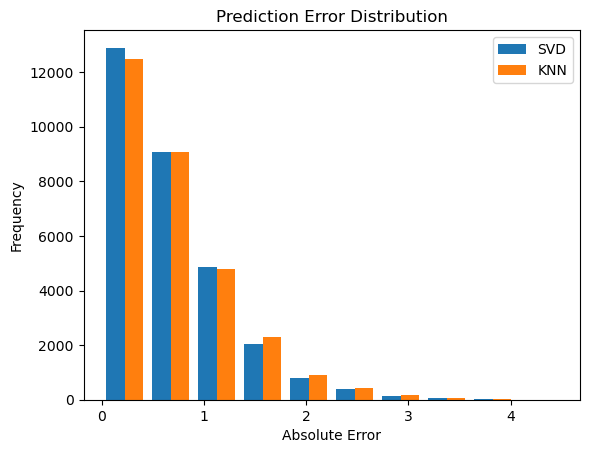

In [126]:
svd_errors = [abs(true - est) for (_, _, true, est, _) in predictions]
knn_errors = [abs(true - est) for (_, _, true, est, _) in knn_user_preds]

plt.hist([svd_errors, knn_errors], label=['SVD', 'KNN'])

plt.title("Prediction Error Distribution")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.legend(loc='upper right')
plt.show()

## Hybrid

In [ ]:
def get_user_stage(user_id, df):
    n = df[df['userId'] == user_id].shape[0]
    
    if n == 0:
        return "new"
    elif n < 10:
        return "near-cold"
    elif n < 50:
        return "early"
    else:
        return "resident"

In [128]:
def recommend_popular(train_df, n=5):
    popular = (
        train_df.groupby('movieId')
        .agg(avg_rating=('rating', 'mean'),
             n_ratings=('rating', 'count'))
        .query('n_ratings >= 20')  # avoid noise
        .sort_values(['avg_rating', 'n_ratings'], ascending=False)
        .head(n)
    )
    
    return movies[movies['movieId'].isin(popular.index)][['title']]

In [129]:
class HybridRecommender:

    def __init__(self, svd_model, tfidf_matrix, movie_df, train_df, trainset, data, alpha=0.7):

        self.svd = svd_model
        self.tfidf_matrix = tfidf_matrix
        self.movie_df = movie_df
        self.train_df = train_df
        self.trainset = trainset
        self.data = data
        self.alpha = alpha

        self.movie_id_to_index = dict(zip(movie_df['movieId'], movie_df.index))

    def get_hybrid_score(self, user_id, movie_id, content_scores):
        
        # SVD prediction
        svd_score = self.svd.predict(user_id, movie_id).est
        
        # Normalize SVD score (MovieLens scale)
        svd_norm = (svd_score - 0.5) / (5.0 - 0.5)

        # Content score
        content_norm = 0
        if movie_id in self.movie_id_to_index:
            idx = self.movie_id_to_index[movie_id]
            content_score = content_scores[idx]
            content_norm = (content_score + 1) / 2  # normalize cosine similarity

        return (self.alpha * svd_norm) + ((1 - self.alpha) * content_norm)

    def recommend(self, user_id, n=10):

        content_scores = get_content_scores(user_id, self.train_df)

        # fallback if no content profile
        if content_scores is None:
            return get_top_n(self.svd, self.trainset, self.data, user_id, n)

        watched = set(self.train_df[self.train_df['userId'] == user_id]['movieId'])

        scores = []

        for m_id in self.movie_df['movieId'].unique():
            if m_id not in watched:
                score = self.get_hybrid_score(user_id, m_id, content_scores)
                scores.append((m_id, score))

        scores.sort(key=lambda x: x[1], reverse=True)

        top_ids = [x[0] for x in scores[:n]]

        return self.movie_df[self.movie_df['movieId'].isin(top_ids)][['title']]

In [ ]:
def router(user_id, df, stage_models):
    
    stage = get_user_stage(user_id, df)
    
    # New / Cold Start Users
    if stage in ["new", "near-cold"]:
        
        popular_recs = recommend_popular(df, n=5)
        content_recs = recommend_content(user_id, df, n=5)
        
        return {
            "stage": stage,
            "recommendations": {
                "popular": popular_recs,
                "content": content_recs
            }
        }
    
    # Early Users to hybrid
    elif stage == "early":
        
        recs = stage_models["hybrid"].recommend(user_id, n=10)
        
        return {
            "stage": stage,
            "recommendations": recs
        }
    
    # Resident Users to SVD
    else:
        
        recs = get_top_n(
            stage_models["svd"],
            stage_models["trainset"],
            stage_models["data"],
            user_id,
            n=10
        )
        
        return {
            "stage": stage,
            "recommendations": recs
        }

**Interpretation:** 

- Brand new users receive recommendations via popularity, if they choose to skip onboarding on the UI

- Near-cold users benefit from both popular picks and content-based personalization

- Early users get hybrid recommendations

- Resident users rely on SVD for optimal personalization




All in all, nsuring better coverage of new users and items & stability across user lifecycle stages

---
## 5: Evaluation

`cumulative gain` - If every recommendation has a graded relevance score associated with it, CG is the sum of graded relevance values of all results in a search result list

**setA: [3, 1, 2, 3, 2, 0]**

**setB: [3, 3, 2, 2, 1, 0]**

CG of setA = 11, CG of setB = 11

*CG doesn't distinguish the order of the list*

`discounted cumulative gain` - penalizes highly relevant documents that appear lower in the search by reducing the graded relevance value logarithimically proportional to the position of the result

hence DCG of setB is higher than setA bc it returned more useful results than setA

`NDCG, ie normalized DCG`, comes into play bc search results list can vary in length

NDCG at K is determined by dividing the Discounted Cumulative Gain (DCG) by the ideal DCG representing a perfect ranking, and can take values from 0 - 1

In [131]:
# NDCG speaks to the Quality of the Ranking

# RMSE speaks to the Quality of the Rating

### 5.1 Collaborative Filtering

#### a) Singular Value Decomposition (SVD)

In [132]:
def compute_ndcg(model, testset, k=10):
    
    user_est_true = {}
    
    for uid, iid, true_r, est, _ in model.test(testset):
        user_est_true.setdefault(uid, []).append((est, true_r))
    
    ndcgs = []
    
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        
        est_scores  = [x[0] for x in user_ratings[:k]]
        true_scores = [x[1] for x in user_ratings[:k]]
        
        if len(set(true_scores)) > 1:
            ndcgs.append(ndcg_score([true_scores], [est_scores]))
    
    return np.mean(ndcgs)

In [133]:
SVD_NDCG = compute_ndcg(best_svd, testset)
print(f"SVD NDCG@10 : {SVD_NDCG:.4f}")

SVD NDCG@10 : 0.9525


In [134]:
prediction = best_svd.test(testset)

SVD_RMSE = accuracy.rmse(prediction)
print(SVD_RMSE)

RMSE: 0.8740
0.8740212706306595


#### b) KNN

In [135]:
def compute_ndcg(best_knn_user, testset, k=10):
    
    user_est_true = {}
    
    for uid, iid, true_r, est, _ in best_knn_user.test(testset):
        user_est_true.setdefault(uid, []).append((est, true_r))
    
    ndcgs = []
    
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        
        est_scores  = [x[0] for x in user_ratings[:k]]
        true_scores = [x[1] for x in user_ratings[:k]]
        
        if len(set(true_scores)) > 1:
            ndcgs.append(ndcg_score([true_scores], [est_scores]))
    
    return np.mean(ndcgs)

In [136]:
KNN_NDCG = compute_ndcg(best_knn_user, testset)
print(f"KNN NDCG@10 : {KNN_NDCG:.4f}")

KNN NDCG@10 : 0.9464


In [137]:
preds_u = best_knn_user.test(testset)

print(accuracy.rmse(preds_u))

RMSE: 0.9071
0.9070791675864917


### 5.2 Content-based Filtering

In [138]:

def get_relevant_items(df, threshold=4.0): # high ratings are treated as relevant
    return (
        df[df['rating'] >= threshold]
        .groupby('userId')['movieId']
        .apply(set)
        .to_dict()
    )


In [139]:
def evaluate_content_ndcg(train_df, test_df, k=10):
    
    relevant_items = get_relevant_items(test_df)
    ndcgs = []
    
    for user_id in relevant_items.keys():
        
        scores = get_content_scores(user_id, train_df)
        
        if scores is None:
            continue
        
        top_idx = scores.argsort()[-k:][::-1]
        
        rec_movie_ids = train_movie_text.iloc[top_idx]['movieId'].tolist()
        
        true_relevance = [
            1 if movie in relevant_items[user_id] else 0
            for movie in rec_movie_ids
        ]
        
        if sum(true_relevance) == 0:
            continue
        
        ndcg = ndcg_score([true_relevance], [scores[top_idx]])
        ndcgs.append(ndcg)
    
    return np.mean(ndcgs)

In [140]:
content_ndcg = evaluate_content_ndcg(train_df, test_df)

print(f"Content-Based NDCG@10: {content_ndcg:.4f}")

Content-Based NDCG@10: 0.5144


### 5.3 Hybrid

In [141]:
def evaluate_hybrid(model, test_df, k=10):

    relevant = get_relevant_items(test_df)
    ndcgs = []

    for user_id in relevant.keys():

        if user_id not in model.train_df['userId'].unique():
            continue

        content_scores = get_content_scores(user_id, model.train_df)

        if content_scores is None:
            continue

        watched = set(model.train_df[model.train_df['userId'] == user_id]['movieId'])

        all_movies = model.movie_df['movieId'].values

        scores = []

        for m_id in all_movies:
            if m_id not in watched:
                score = model.get_hybrid_score(user_id, m_id, content_scores)
                scores.append((m_id, score))

        scores.sort(key=lambda x: x[1], reverse=True)

        top_k = scores[:k]

        rec_movies = [m for m, _ in top_k]
        pred_scores = [s for _, s in top_k]

        true_rel = [
            1 if m in relevant[user_id] else 0
            for m in rec_movies
        ]

        if sum(true_rel) == 0:
            continue

        ndcgs.append(ndcg_score([true_rel], [pred_scores]))

    return np.mean(ndcgs)

In [142]:
hybrid_model = HybridRecommender(
    best_svd,
    tfidf_matrix,
    train_movie_text,
    train_df,
    trainset,
    data
)

In [143]:
hybrid_ndcg = evaluate_hybrid(hybrid_model, test_df, k=10)

print(f"Hybrid NDCG@10: {hybrid_ndcg:.4f}")

Hybrid NDCG@10: 0.6282


In [144]:
results = pd.DataFrame({
    "Model": ["SVD", "KNN (User)", "Content-Based", "Hybrid"],
    "RMSE": [SVD_RMSE, knn_user_rmse, None, None],
    "NDCG@10": [SVD_NDCG, KNN_NDCG, content_ndcg, hybrid_ndcg]
})

results.sort_values("NDCG@10", ascending=False)

,Model,RMSE,NDCG@10
0,SVD,0.874021,0.952510
1,KNN (User),0.907214,0.946447
3,Hybrid,NaN,0.628194
2,Content-Based,NaN,0.514354


The superior performance of collaborative filtering adds up given the structure of the dataset. With over 100,000 ratings across hundreds of users, the interaction matrix is sufficiently dense for matrix factorization methods to learn stable latent factors. In contrast, content-based filtering is constrained by limited semantic richness in movie metadata (genres and sparse tags)

---
## 6: Conclusion

Collaborative filtering outperformed both hybrid and content-based models in NDCG@10, indicating that user–user interaction patterns are the strongest signal in this dataset.

This suggests that the platform should prioritise collaborative filtering as the primary ranking engine, while using hybrid/content-based methods as fallback strategies for users with limited interactions

---
## 7: Deployment setup

In [ ]:
import pickle # for serialization, ie converting the model to a storable format

# Save essential components
data_to_save = {
    'svd_model': best_svd,
    'tfidf_matrix': tfidf_matrix,
    'movie_df': train_movie_text,
    'train_df': train_df,
    'trainset': trainset,
    'raw_data': data
}

with open('recommender_model.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)